# The Data

## Importing the data 

In [1]:
import kagglehub 
# Download latest version
path = kagglehub.dataset_download("utkarshx27/american-companies-bankruptcy-prediction-dataset")

print("Path to dataset files:", path)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/jonas/.cache/kagglehub/datasets/utkarshx27/american-companies-bankruptcy-prediction-dataset/versions/3


In [72]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
print(os.listdir(path))
original_dataset= pd.read_csv(path + "/american_bankruptcy.csv")
original_dataset.to_csv("forchat.csv",index=False)
n_firms = original_dataset["company_name"].nunique()
print(n_firms)





['american_bankruptcy.csv']
8971


## Sample construction

In [73]:
# Sort the dataset 
original_dataset= original_dataset.sort_values(["company_name", "year"])

# Makes a new column with "alive" as default
original_dataset["new_status"] = "alive"

mask_failed = original_dataset.groupby("company_name")["status_label"].transform(lambda x: (x == "failed").any())
mask_last = original_dataset["year"] == original_dataset.groupby("company_name")["year"].transform("max")

original_dataset.loc[mask_failed & mask_last, "new_status"] = "failed"

# Testing as C_20 is bankrupt 
original_dataset[original_dataset["company_name"] == "C_20"]



,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,X10,X11,X12,X13,X14,X15,X16,X17,X18,new_status
239,C_20,failed,1999,264.225,3976.624,6.071,14.034,21.475,6.387,216.978,...,293.048,9.900,7.963,18.853,244.787,23.906,3995.477,257.027,3981.443,alive
240,C_20,failed,2000,420.349,6996.091,6.745,19.606,35.453,8.840,346.152,...,448.044,11.900,12.861,26.069,387.743,32.198,7022.160,403.731,7002.554,alive
241,C_20,failed,2001,199.305,4715.132,6.726,-5.784,10.004,-4.569,167.556,...,227.027,11.475,-12.510,2.110,168.971,27.081,4717.242,187.831,4723.026,alive
242,C_20,failed,2002,179.054,2307.357,5.565,7.787,6.591,1.452,141.852,...,202.120,11.475,2.222,15.960,147.762,27.985,2323.317,162.020,2315.530,alive
243,C_20,failed,2003,185.651,1700.737,5.665,14.893,6.874,3.102,140.425,...,210.261,11.475,9.228,21.192,152.665,30.117,1721.929,168.029,1707.036,alive
244,C_20,failed,2004,209.339,2041.384,6.572,20.537,11.372,8.608,169.680,...,238.854,11.475,13.965,28.404,173.550,37.460,2069.788,189.279,2049.251,alive
245,C_20,failed,2005,270.450,2329.094,7.060,26.071,11.692,17.641,232.355,...,312.662,11.475,19.011,35.739,231.129,53.541,2364.833,247.006,2338.762,alive
246,C_20,failed,2006,241.790,2213.615,9.485,24.452,7.950,10.483,208.633,...,289.287,3.000,14.967,32.988,206.582,62.253,2246.603,214.919,2222.151,alive
247,C_20,failed,2007,311.893,2602.035,11.384,23.213,14.776,17.056,269.652,...,357.075,0.000,11.829,34.187,261.321,77.327,2636.222,267.633,2613.009,alive
248,C_20,failed,2008,169.366,4148.106,13.373,1.899,14.207,-5.572,123.030,...,210.926,0.000,-11.474,11.566,127.807,69.646,4159.672,129.165,4157.773,alive


### Creating binary target variable 

In [ ]:
original_dataset["bankruptcy"] = (original_dataset["new_status"] == "failed").astype(int)
original_dataset[original_dataset["bankruptcy"] == 1].sort_index()

#original_dataset.drop(columns="status_label", inplace=True)
original_dataset.drop(columns="new_status", inplace=True)
original_dataset.info()


<class 'pandas.core.frame.DataFrame'>
Index: 78682 entries, 0 to 11925
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   company_name  78682 non-null  object 
 1   year          78682 non-null  int64  
 2   X1            78682 non-null  float64
 3   X2            78682 non-null  float64
 4   X3            78682 non-null  float64
 5   X4            78682 non-null  float64
 6   X5            78682 non-null  float64
 7   X6            78682 non-null  float64
 8   X7            78682 non-null  float64
 9   X8            78682 non-null  float64
 10  X9            78682 non-null  float64
 11  X10           78682 non-null  float64
 12  X11           78682 non-null  float64
 13  X12           78682 non-null  float64
 14  X13           78682 non-null  float64
 15  X14           78682 non-null  float64
 16  X15           78682 non-null  float64
 17  X16           78682 non-null  float64
 18  X17           78682 non-null  f

### Creating regimes 


In [163]:
df_model_1= original_dataset.copy()

df_model_1["regime"] = "outside"

df_model_1.loc[(df_model_1["year"] >= 2003) & (df_model_1["year"] <= 2007), "regime"] = "pre_crisis"
df_model_1 .loc[(df_model_1["year"] >= 2008) & (df_model_1["year"] <= 2010), "regime"] = "crisis"
df_model_1.loc[(df_model_1["year"] >= 2011) & (df_model_1["year"] <= 2018), "regime"] = "post_crisis"

df_model_1["regime"].value_counts()

# The three regimes 
df_filtered = df_model_1[df_model_1["regime"].isin(["pre_crisis", "crisis", "post_crisis"])]

unique_values = df_filtered["company_name"].nunique()
total_observations= df_filtered.shape[0]

# OUTSIDE 
df_filtered_outside = df_model_1[df_model_1["regime"].isin(["outside"])]

total_observations_outside= df_filtered_outside.shape[0]

summary = pd.DataFrame({
    "Total observations": [total_observations, total_observations_outside,total_observations + total_observations_outside],
    "Unique values": [unique_values,"",""]

},index=["Pre, Crisis, Post","Outside", "Total"])

summary



,Total observations,Unique values
"Pre, Crisis, Post",58600,7301
Outside,20082,
Total,78682,


## Feature creation 

In [ ]:

# renaming the features #
df_model_1.rename(columns={
    'X1':'current_assets',
    'X2':'cost_of_goods_sold',
    'X3':'depreciation_and_amortization',
    'X4':'ebitda',
    'X5':'inventory',
    'X6':'net_income',
    'X7':'total_receivables',
    'X8':'market_value',
    'X9':'net_sales',
    'X10':'total_assets',
    'X11':'total_long_term_debt',
    'X12':'ebit',
    'X13':'gross_profit',
    'X14':'total_current_liabilities',
    'X15':'retained_earnings',
    'X16':'total_revenue',
    'X17':'total_liabilities',
    'X18':'total_operating_expenses'}, inplace = True)

# df_model_1.info()

# Creating financial ratios 


df = df_model_1.copy()

# --- Liquidity ---
df["current_ratio"] = df["current_assets"] / df["total_current_liabilities"]
df["working_capital_ratio"] = (df["current_assets"] - df["total_current_liabilities"]) / df["total_assets"]
df["receivables_liquidity_ratio"] = df["total_receivables"] / df["total_current_liabilities"]

# --- Leverage ---
df["debt_ratio"] = df["total_liabilities"] / df["total_assets"]
df["long_term_debt_ratio"] = df["total_long_term_debt"] / df["total_assets"]
df["debt_to_sales"] = df["total_liabilities"] / df["net_sales"]
df["debt_to_revenue"] = df["total_liabilities"] / df["total_revenue"]
df["current_liabilities_ratio"] = df["total_current_liabilities"] / df["total_assets"]
df["market_to_liability"] = df["market_value"] / df["total_liabilities"]

# --- Profitability ---
df["roa_net_income"] = df["net_income"] / df["total_assets"]
df["profit_margin"] = df["net_income"] / df["net_sales"]
df["ebit_margin"] = df["ebit"] / df["net_sales"]
df["gross_margin"] = df["gross_profit"] / df["net_sales"]

# --- Turnover ---
df["asset_turnover"] = df["net_sales"] / df["total_assets"]
df["receivables_turnover"] = df["net_sales"] / df["total_receivables"]
df["inventory_turnover"] = df["cost_of_goods_sold"] / df["inventory"]
df["operating_expense_ratio"] = df["total_operating_expenses"] / df["net_sales"]

# --- Cash flow / operating ---
df["ebitda_to_assets"] = df["ebitda"] / df["total_assets"]
df["ebitda_to_liabilities"] = df["ebitda"] / df["total_liabilities"]
df["ebitda_to_sales"] = df["ebitda"] / df["net_sales"]
df["operating_expense_burden"] = df["total_operating_expenses"] / df["total_assets"]

# --- Size ---
df["log_total_assets"] = np.log(df["total_assets"])
df["log_net_sales"] = np.log(df["net_sales"])
df["log_market_value"] = np.log(df["market_value"])

# --- Other ---
df["market_to_assets"] = df["market_value"] / df["total_assets"]
df["retained_earnings_to_assets"] = df["retained_earnings"] / df["total_assets"]

df["company_name"].value_counts()
df.info()






<class 'pandas.core.frame.DataFrame'>
Index: 78682 entries, 0 to 11925
Data columns (total 48 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   company_name                   78682 non-null  object 
 1   year                           78682 non-null  int64  
 2   current_assets                 78682 non-null  float64
 3   cost_of_goods_sold             78682 non-null  float64
 4   depreciation_and_amortization  78682 non-null  float64
 5   ebitda                         78682 non-null  float64
 6   inventory                      78682 non-null  float64
 7   net_income                     78682 non-null  float64
 8   total_receivables              78682 non-null  float64
 9   market_value                   78682 non-null  float64
 10  net_sales                      78682 non-null  float64
 11  total_assets                   78682 non-null  float64
 12  total_long_term_debt           78682 non-null  floa

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


## Balance of the dataset 

In [102]:
print(df_model_1.groupby("regime")["bankruptcy"].value_counts(dropna=False, normalize=True))
print(df_model_1.groupby("regime")["bankruptcy"].value_counts(dropna=False))

regime       bankruptcy
crisis       0             0.989666
             1             0.010334
outside      0             0.998158
             1             0.001842
post_crisis  0             0.991206
             1             0.008794
pre_crisis   0             0.989340
             1             0.010660
Name: proportion, dtype: float64
regime       bankruptcy
crisis       0             11109
             1               116
outside      0             20045
             1                37
post_crisis  0             26037
             1               231
pre_crisis   0             20882
             1               225
Name: count, dtype: int64


## Distribution, Missing values  and outliers 

### Dropping level variables

In [ ]:
df_final_dataset = df.copy()

df_final_dataset.drop(columns={
    'current_assets',
    'cost_of_goods_sold',
    'depreciation_and_amortization',
    'ebitda',
    'inventory',
    'net_income',
    'total_receivables',
    'market_value',
    'net_sales',
    'total_assets',
    'total_long_term_debt',
    'ebit',
    'gross_profit',
    'total_current_liabilities',
    'retained_earnings',
    'total_revenue',
    'total_liabilities',
    'total_operating_expenses'}, inplace = True)

df_final_dataset.info()



### Missing values

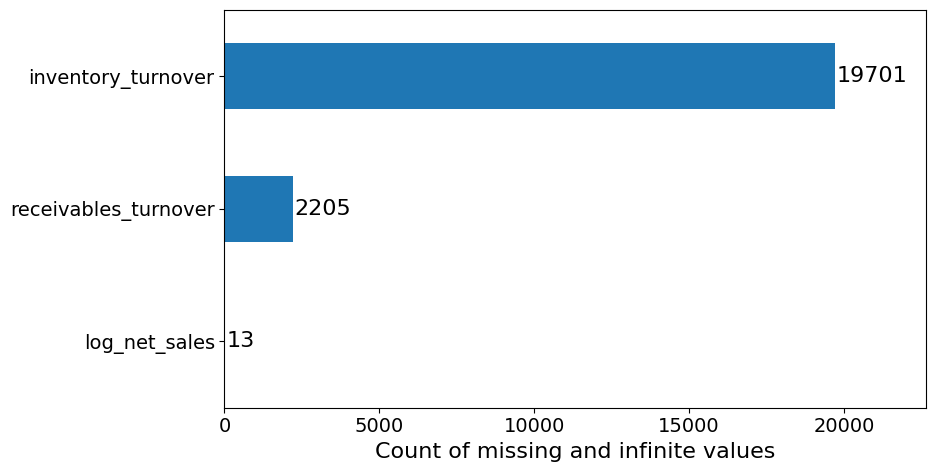

19422


np.int64(13)

In [ ]:
# Count infinite values for each numeric variable
inf_values = np.isinf(
    df_final_dataset.select_dtypes(include=[np.number])
).sum()

# Reindex so non-numeric variables also appear with 0 infinite values
inf_values = inf_values.reindex(df_final_dataset.columns, fill_value=0)

# Counting missing values 
Missing_values= (df_final_dataset.isna().sum())
total_missingness = inf_values + Missing_values


problem_values = total_missingness[total_missingness > 0].sort_values()

ax = problem_values.plot(kind="barh", figsize=(10, 5))

ax.set_xlabel("Count of missing and infinite values")


# Add exact values at end of bars
for i, value in enumerate(problem_values):
    ax.text(value + 50, i, str(int(value)), va="center")

plt.tight_layout()
ax.set_xlim(0, problem_values.max() * 1.15)
plt.savefig("missing_values.pdf", bbox_inches="tight")
plt.show()




#### creating binary variable for inventory=0 

In [221]:


#df_final_dataset["zero_inventory"] = (
   # df_final_dataset["inventory_turnover"].isna() |
    #np.isinf(df_final_dataset["inventory_turnover"])
#).astype(int)

df_final_dataset["zero_inventory"].value_counts()


#dropping the inventory_turnover
#df_final_dataset = df_final_dataset.drop(columns=["inventory_turnover"])
df_final_dataset.info()



<class 'pandas.core.frame.DataFrame'>
Index: 78682 entries, 0 to 11925
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   company_name                 78682 non-null  object 
 1   year                         78682 non-null  int64  
 2   bankruptcy                   78682 non-null  int64  
 3   regime                       78682 non-null  object 
 4   current_ratio                78682 non-null  float64
 5   working_capital_ratio        78682 non-null  float64
 6   receivables_liquidity_ratio  78682 non-null  float64
 7   debt_ratio                   78682 non-null  float64
 8   long_term_debt_ratio         78682 non-null  float64
 9   debt_to_sales                78682 non-null  float64
 10  debt_to_revenue              78682 non-null  float64
 11  current_liabilities_ratio    78682 non-null  float64
 12  market_to_liability          78682 non-null  float64
 13  roa_net_income       

#### Dropping observations where log sales is missing. 

In [224]:
df_final_dataset = df_final_dataset.dropna(subset=["log_net_sales"])

df_final_dataset["log_net_sales"].isna().sum()
df_final_dataset.shape
df_final_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 78669 entries, 0 to 11925
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   company_name                 78669 non-null  object 
 1   year                         78669 non-null  int64  
 2   bankruptcy                   78669 non-null  int64  
 3   regime                       78669 non-null  object 
 4   current_ratio                78669 non-null  float64
 5   working_capital_ratio        78669 non-null  float64
 6   receivables_liquidity_ratio  78669 non-null  float64
 7   debt_ratio                   78669 non-null  float64
 8   long_term_debt_ratio         78669 non-null  float64
 9   debt_to_sales                78669 non-null  float64
 10  debt_to_revenue              78669 non-null  float64
 11  current_liabilities_ratio    78669 non-null  float64
 12  market_to_liability          78669 non-null  float64
 13  roa_net_income       

#### Elaboration on missing values 

In [ ]:

print(np.isinf(df_final_dataset["inventory_turnover"]).sum())
Missing= (df_final_dataset["inventory_turnover"].isna().sum())
Missing
df_final_dataset["log_net_sales"].isna().sum()



print("net_sales <= 0:", (df["net_sales"] <= 0).sum())
print("market_value <= 0:", (df["market_value"] <= 0).sum())
print("inventory == 0:", (df["inventory"] == 0).sum())
print("cost_of_goods_sold <= 0:", (df["cost_of_goods_sold"] <= 0).sum())
print(
    "inventory == 0 and cost_of_goods_sold == 0:",
    ((df["inventory"] == 0) & (df["cost_of_goods_sold"] == 0)).sum()
)
df.loc[df["net_sales"] <= 0, ["net_sales", "bankruptcy"]]

## Outliers of the features 

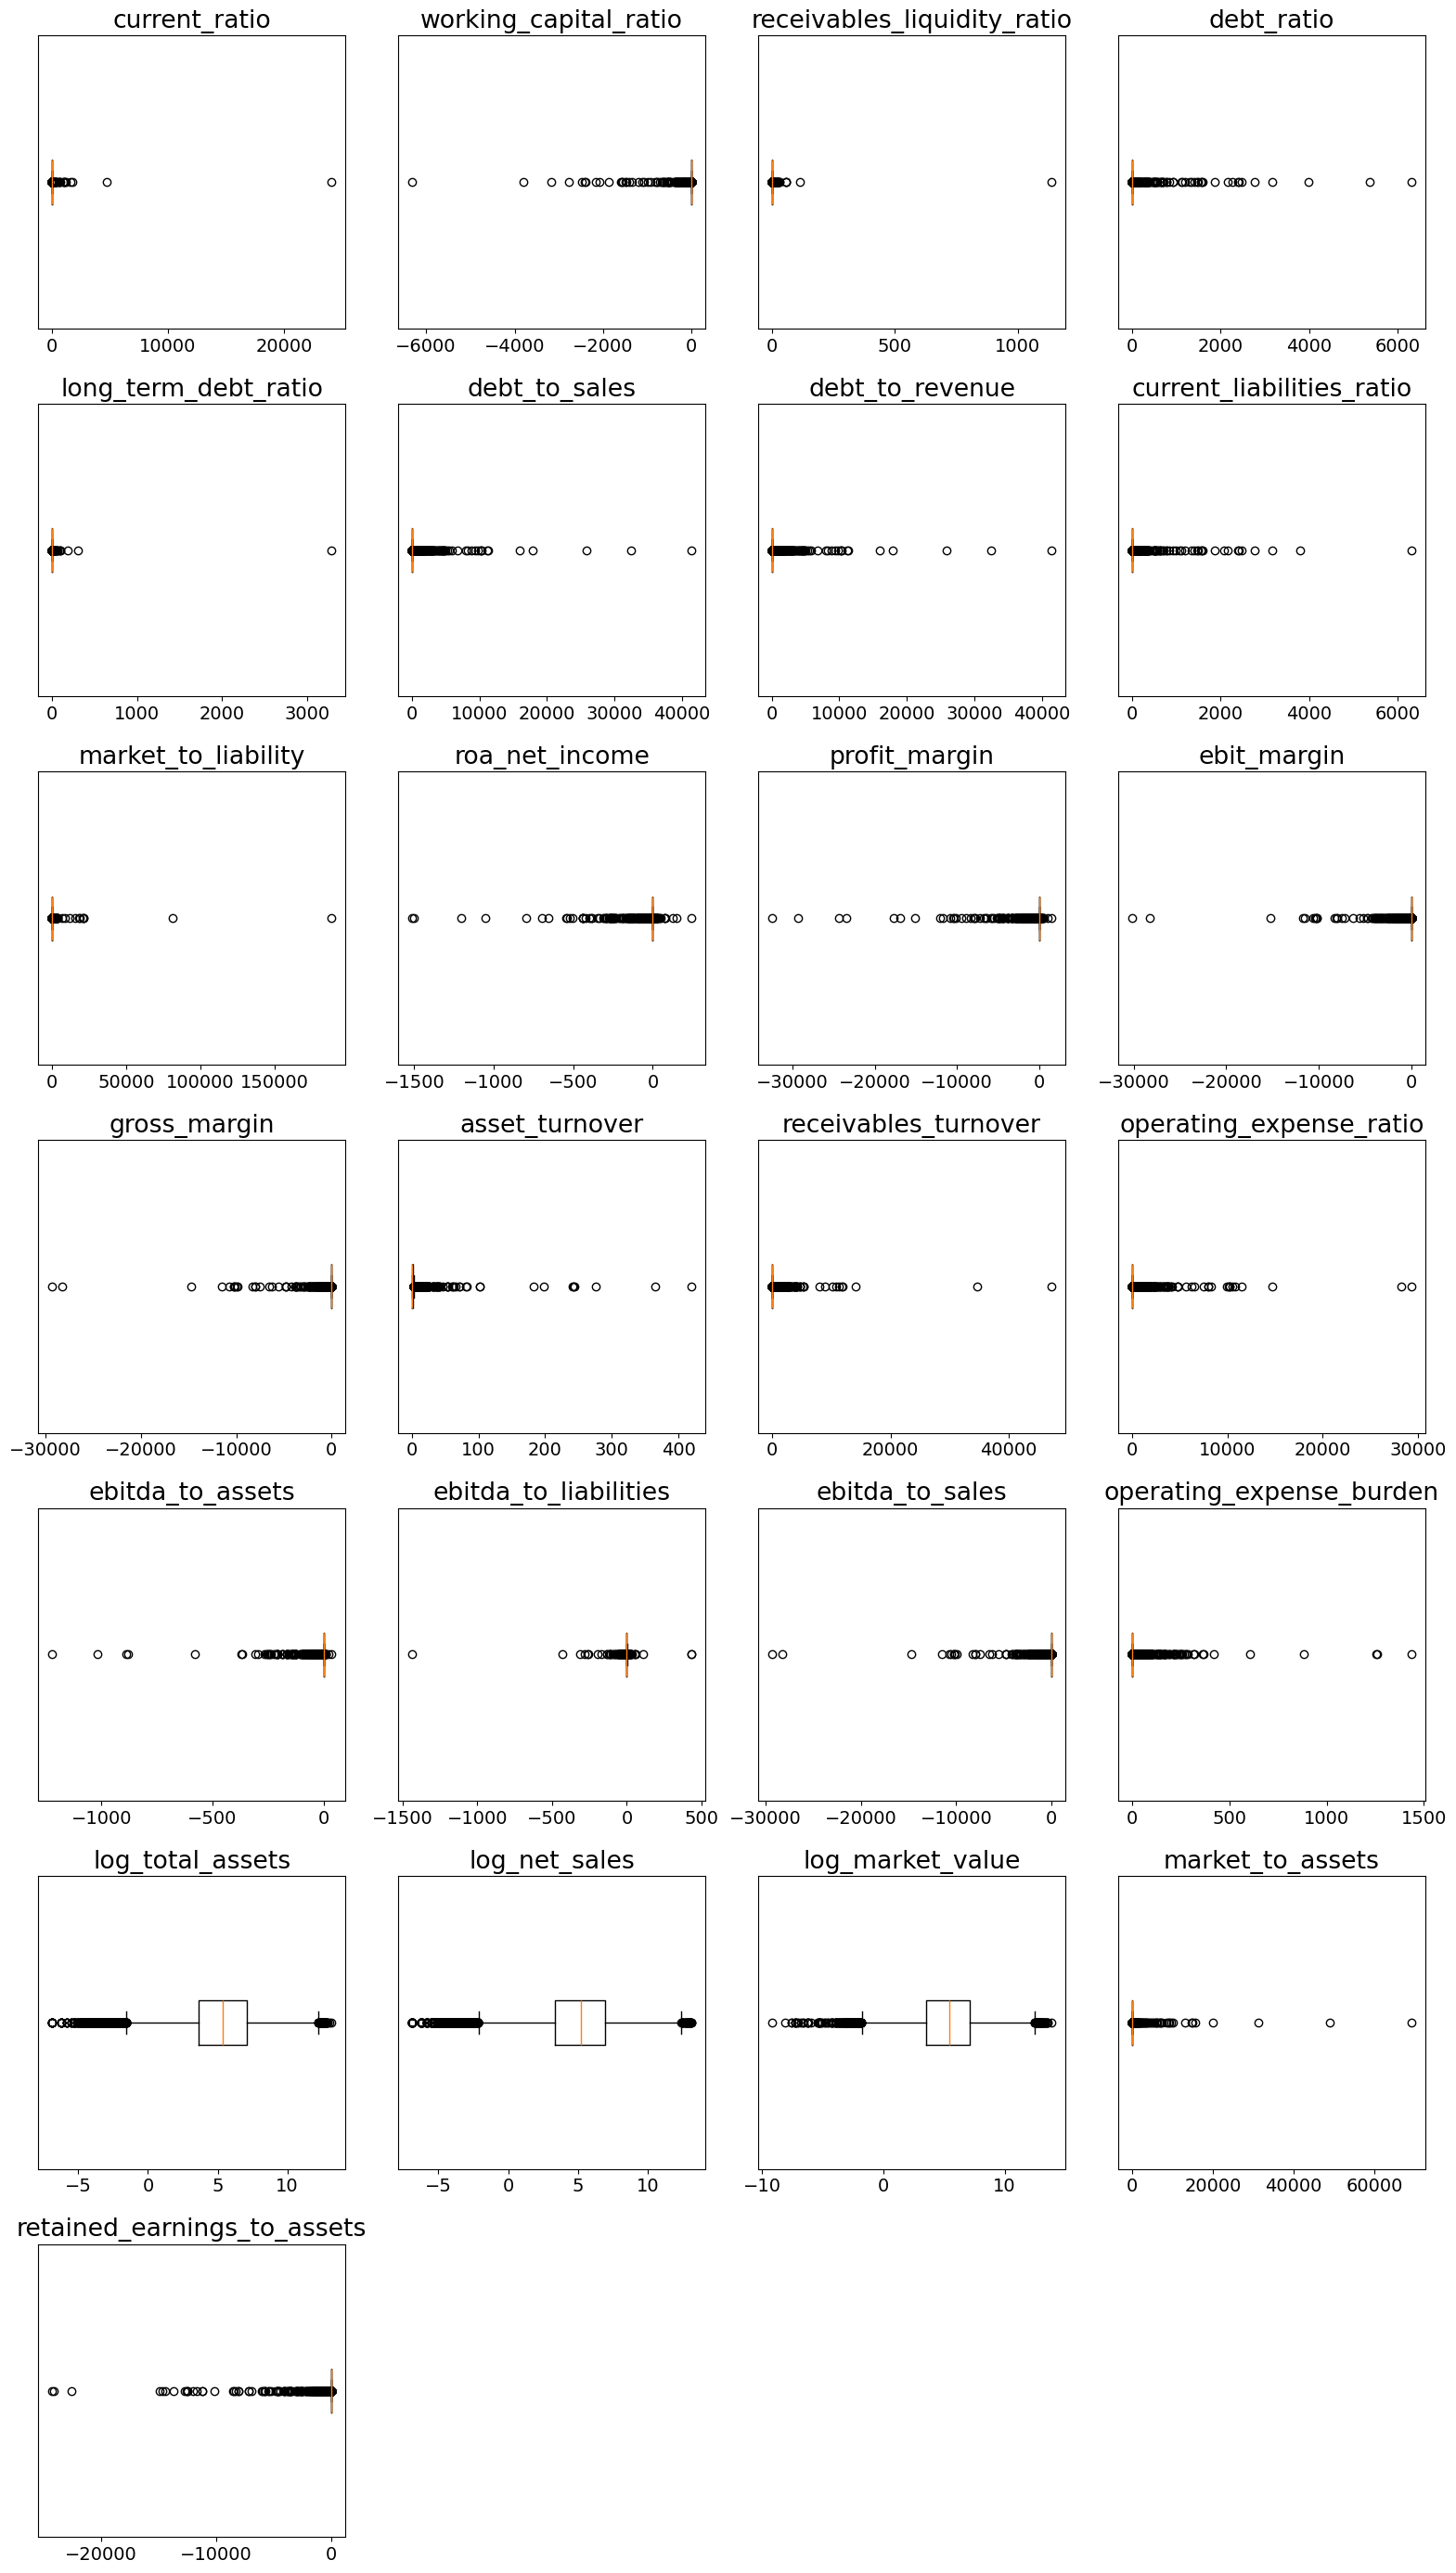

In [ ]:

import math


continuous_features = df_final_dataset.drop(
    columns=["company_name", "regime", "year", "bankruptcy", "zero_inventory"]
)
continuous_features = continuous_features.select_dtypes(include=[np.number])

# Grid settings
n_cols = 4
n_vars = len(continuous_features.columns)
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(continuous_features.columns):
    data = continuous_features[col].dropna()
    axes[i].boxplot(data, vert=False)
    axes[i].set_title(col)
    axes[i].set_yticks([])

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("boxplots_grid.pdf", bbox_inches="tight")
plt.show()

#### Distributions 

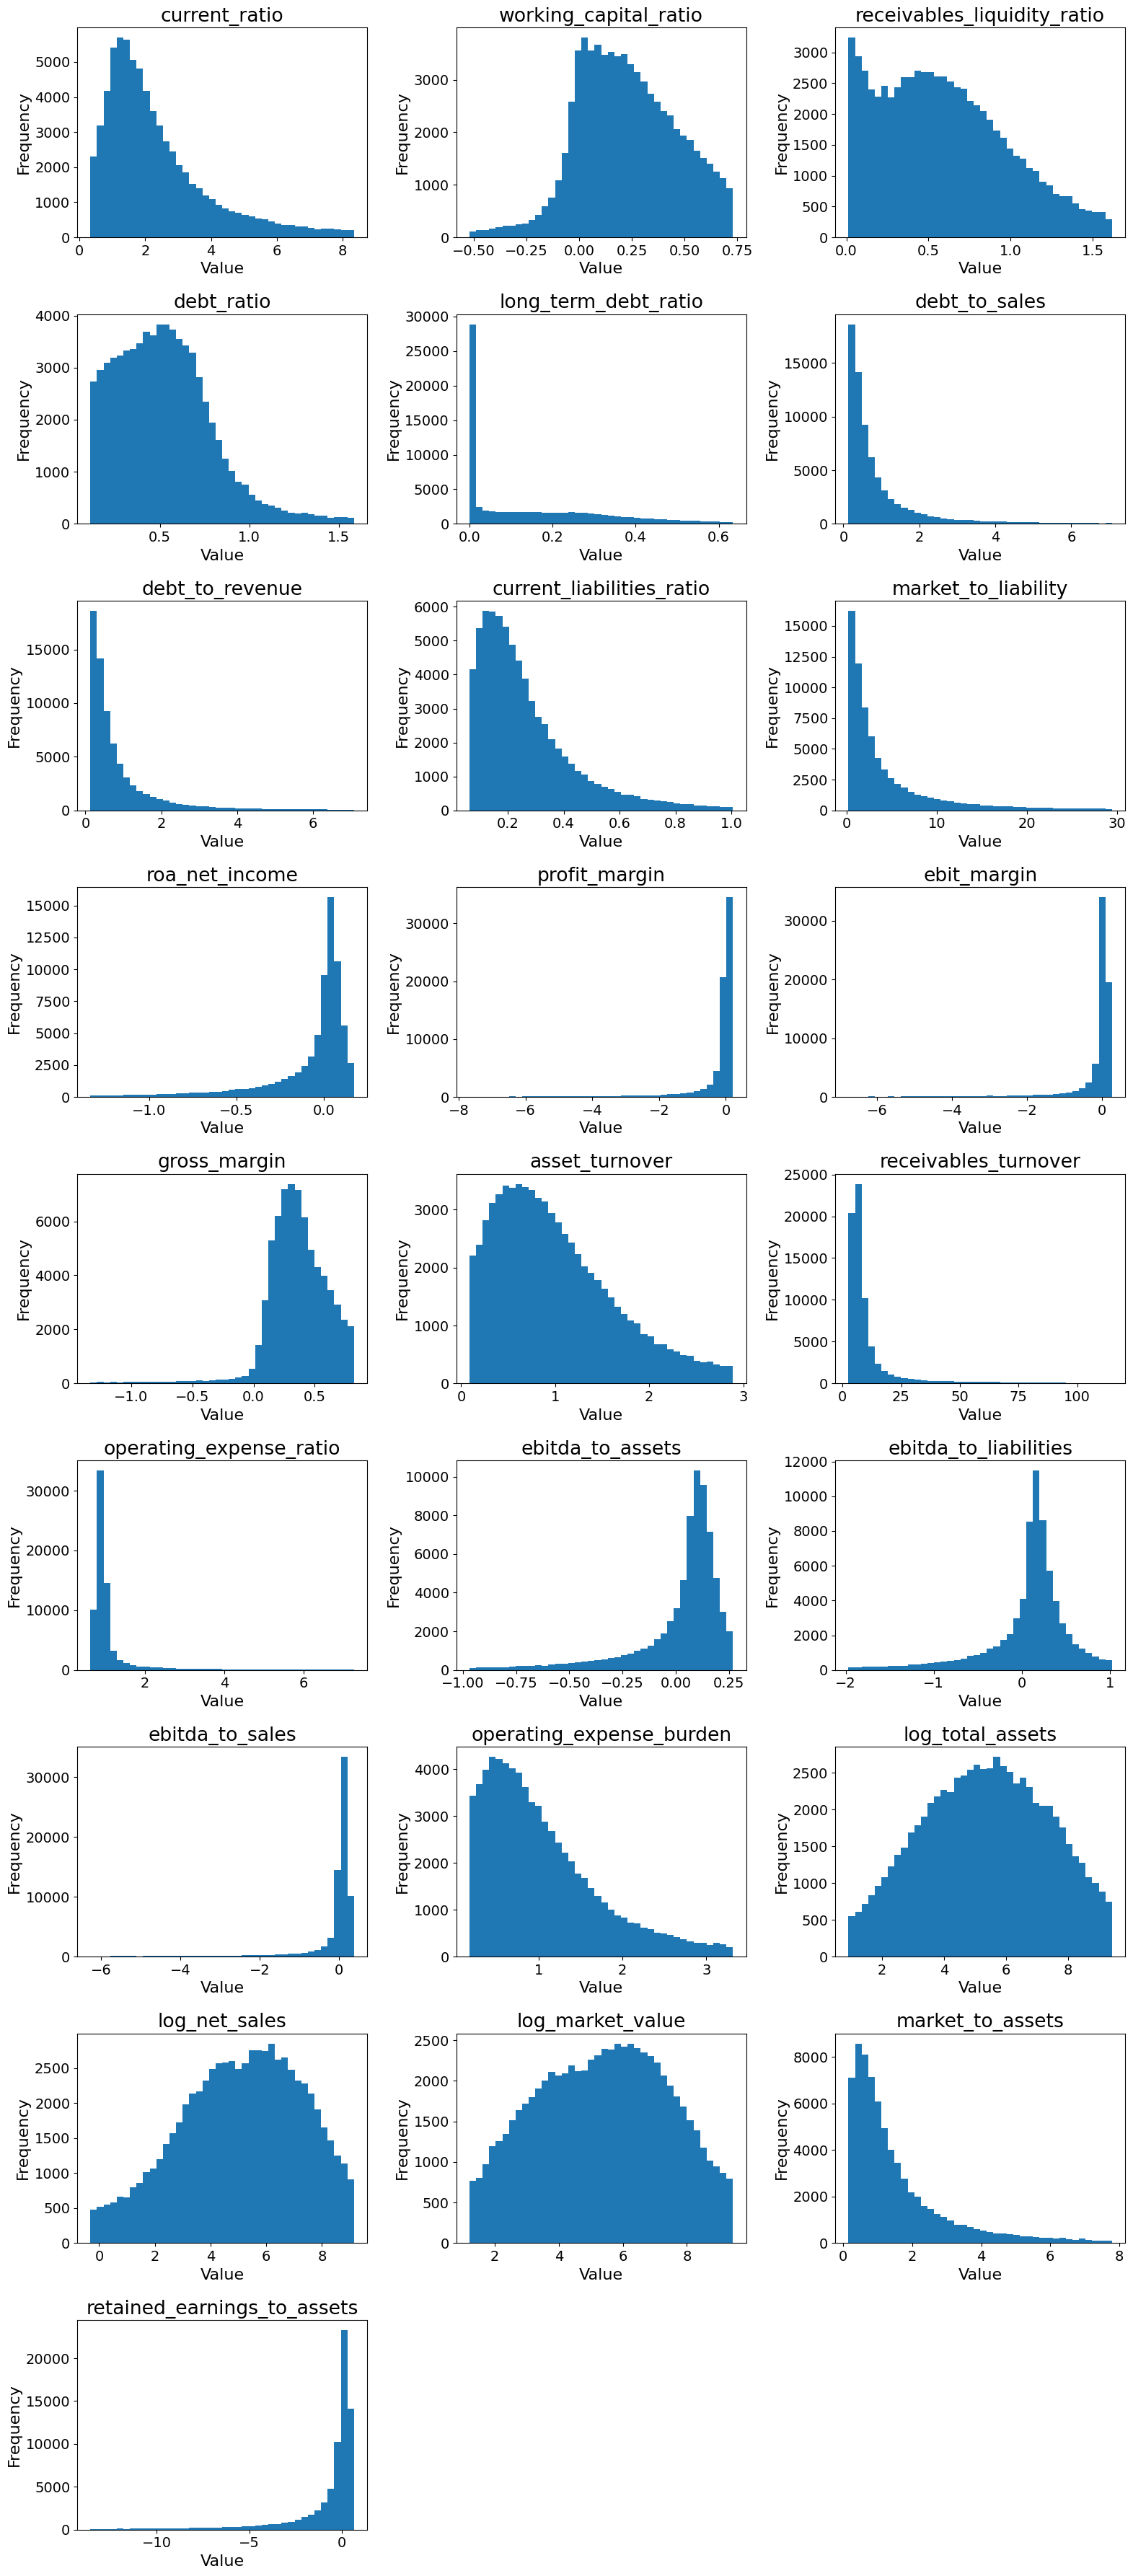

In [236]:
continuous_features = df_final_dataset.drop(
    columns=["company_name", "regime", "year", "bankruptcy", "zero_inventory"],
    errors="ignore"
)

continuous_features = continuous_features.select_dtypes(include=[np.number])

# Choose zoom range
lower_q = 0.05
upper_q = 0.95

# Grid settings
n_cols = 3
n_vars = len(continuous_features.columns)
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(continuous_features.columns):
    data = continuous_features[col].dropna()

    lower = data.quantile(lower_q)
    upper = data.quantile(upper_q)

    # Keep only central observations for plotting
    data_zoomed = data[(data >= lower) & (data <= upper)]

    axes[i].hist(data_zoomed, bins=40)
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("distribution_plots_zoomed.pdf", bbox_inches="tight")
plt.show()

## Correlation between features

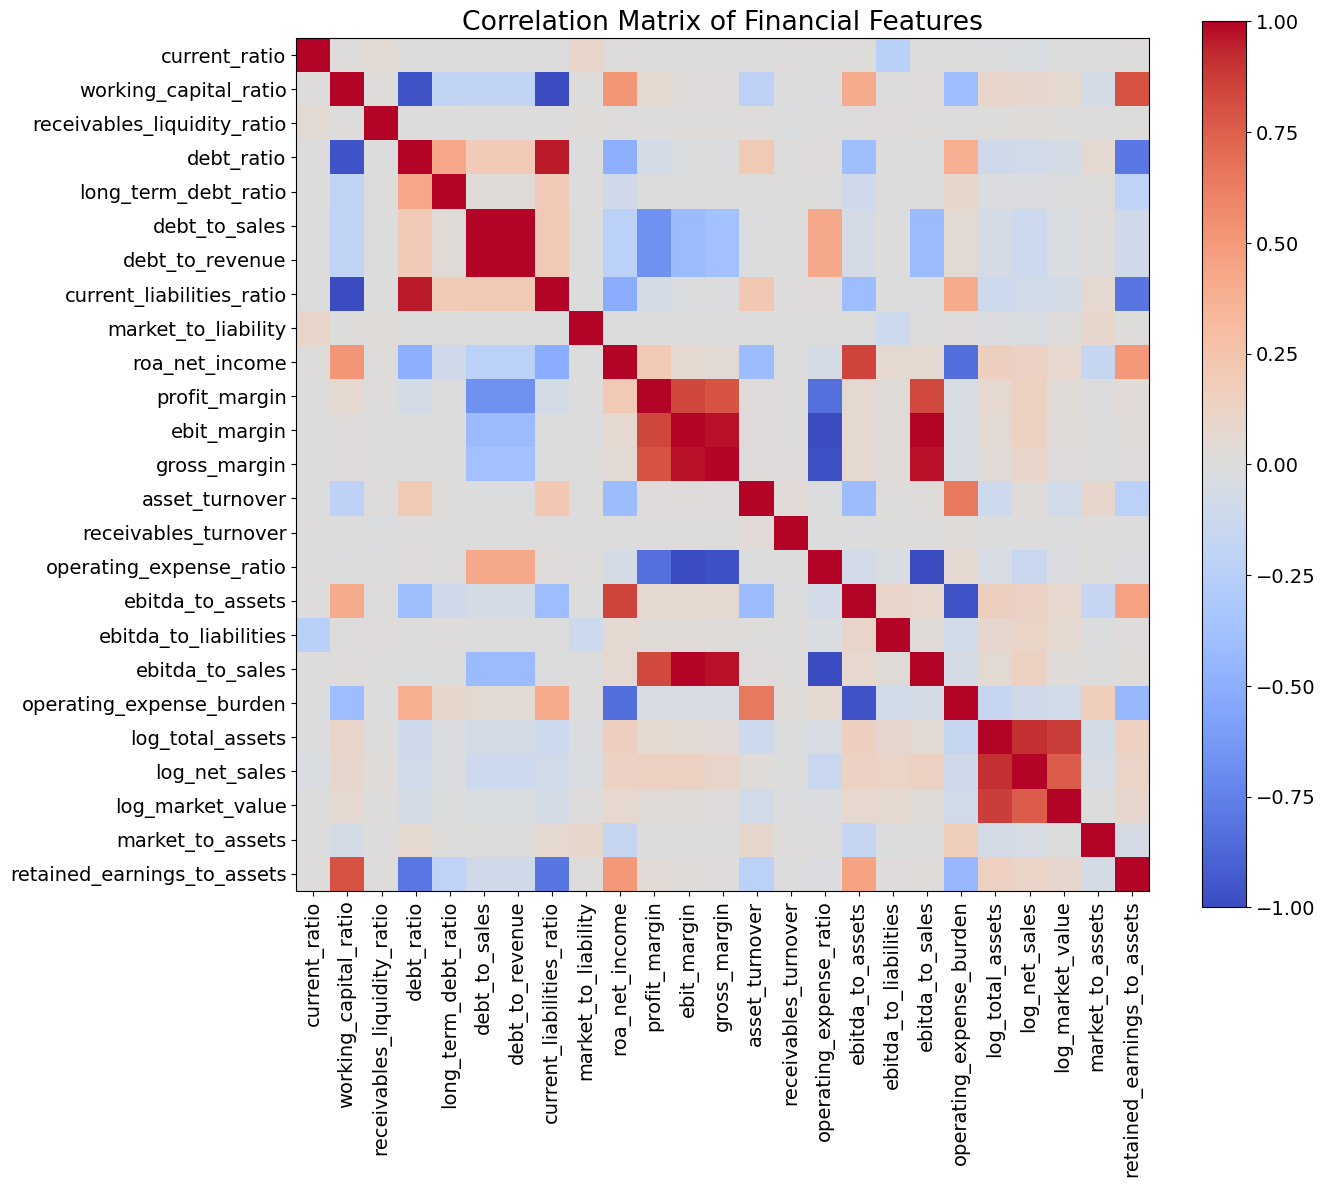

In [237]:
continuous_features = df_final_dataset.drop(
    columns=["company_name", "regime", "year", "bankruptcy", "zero_inventory"]
)
continuous_features = continuous_features.select_dtypes(include=[np.number])

corr_matrix = continuous_features.corr()

fig, ax = plt.subplots(figsize=(14, 12))

im = ax.imshow(corr_matrix,cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))

ax.set_xticklabels(corr_matrix.columns, rotation=90)
ax.set_yticklabels(corr_matrix.columns)

fig.colorbar(im, ax=ax)

ax.set_title("Correlation Matrix of Financial Features")

plt.tight_layout()
plt.savefig("correlation_matrix_features.pdf", bbox_inches="tight")
plt.show()